In [1]:
# =============================================================================
# Notebook 06 — Model Improvements
# Credit Card Fraud Detection
# =============================================================================

# ── 1. IMPORT LIBRARIES ───────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    roc_curve
)

import shap
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

os.makedirs("../reports/tables", exist_ok=True)
os.makedirs("../models/improved", exist_ok=True)

In [2]:
# ── 2. LOAD DATA ──────────────────────────────────────────────────────────────

X_train_scaled = pd.read_csv("../data/processed/X_train_scaled.csv")
X_test_scaled  = pd.read_csv("../data/processed/X_test_scaled.csv")
y_train        = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test         = pd.read_csv("../data/processed/y_test.csv").squeeze()

X_train_resampled = pd.read_csv("../data/processed/X_train_resampled.csv")
y_train_resampled = pd.read_csv("../data/processed/y_train_resampled.csv").squeeze()

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

Train shape: (227845, 30)
Test shape : (56962, 30)


In [3]:
# ── 3. HELPER: EVALUATE MODEL ─────────────────────────────────────────────────

def evaluate_model(model_name, y_true, y_pred, y_prob):
    return {
        "Model"    : model_name,
        "Accuracy" : accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall"   : recall_score(y_true, y_pred, zero_division=0),
        "F1-Score" : f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC"  : roc_auc_score(y_true, y_prob),
        "PR-AUC"   : average_precision_score(y_true, y_prob)
    }


=== STEP 1: FEATURE SELECTION USING SHAP ===
Feature  Mean |SHAP|
    V14     2.889125
     V4     1.703566
    V12     1.050811
    V11     0.824844
    V10     0.775173
   Time     0.575760
     V3     0.560851
     V8     0.544230
    V19     0.444158
 Amount     0.439192
    V16     0.436679
     V7     0.401965
    V15     0.392666
    V26     0.385406
     V1     0.332982
    V24     0.308518
    V13     0.300744
    V22     0.298949
    V20     0.273045
     V5     0.263592
    V21     0.259513
     V9     0.245246
     V6     0.244325
    V18     0.243501
    V27     0.243138
     V2     0.233101
    V23     0.224968
    V25     0.221797
    V17     0.193825
    V28     0.179052


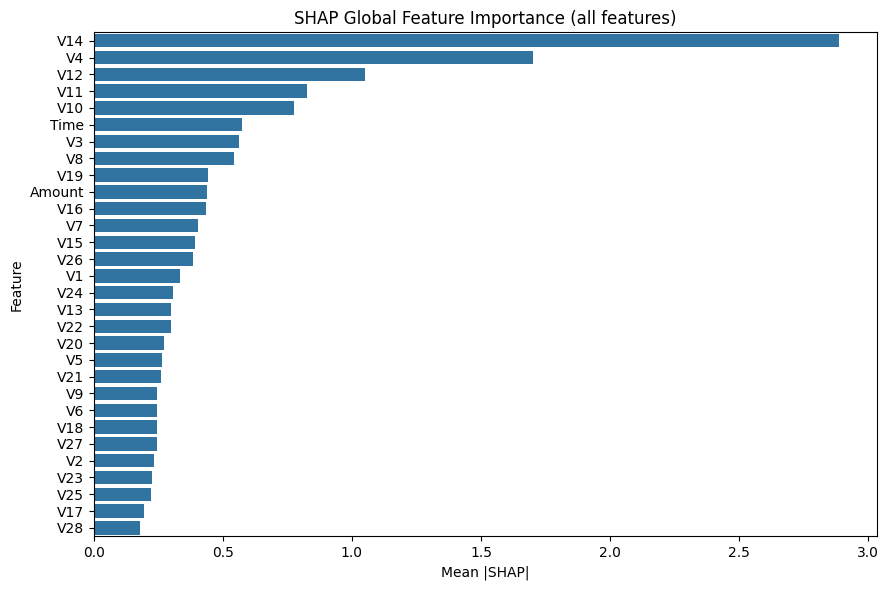


SHAP threshold : 0.5164
Features kept  : 8 -> ['V14', 'V4', 'V12', 'V11', 'V10', 'Time', 'V3', 'V8']
Features dropped: 22 -> ['V1', 'V2', 'V5', 'V6', 'V7', 'V9', 'V13', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']


In [4]:
# ── 4. FEATURE SELECTION USING SHAP ──────────────────────────────────────────

print("\n=== STEP 1: FEATURE SELECTION USING SHAP ===")

final_xgb   = joblib.load("../models/final/best_xgboost_model.pkl")
explainer   = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_test_scaled)

mean_abs_shap = np.abs(shap_values).mean(axis=0)

feature_importance_df = pd.DataFrame({
    "Feature"    : X_test_scaled.columns,
    "Mean |SHAP|": mean_abs_shap
}).sort_values("Mean |SHAP|", ascending=False)

print(feature_importance_df.to_string(index=False))

plt.figure(figsize=(9, 6))
sns.barplot(data=feature_importance_df, x="Mean |SHAP|", y="Feature")
plt.title("SHAP Global Feature Importance (all features)")
plt.tight_layout()
plt.savefig("../reports/tables/shap_all_features.png", dpi=150)
plt.show()

# Keep features above the mean of all mean |SHAP| values
shap_threshold    = mean_abs_shap.mean()
selected_features = feature_importance_df[
    feature_importance_df["Mean |SHAP|"] >= shap_threshold
]["Feature"].tolist()
dropped_features  = [f for f in X_test_scaled.columns if f not in selected_features]

print(f"\nSHAP threshold : {shap_threshold:.4f}")
print(f"Features kept  : {len(selected_features)} -> {selected_features}")
print(f"Features dropped: {len(dropped_features)} -> {dropped_features}")

X_train_sel           = X_train_scaled[selected_features]
X_test_sel            = X_test_scaled[selected_features]
X_train_resampled_sel = X_train_resampled[selected_features]

In [5]:
# ── 5. FIXED XGBOOST TUNING ───────────────────────────────────────────────────
# Key fixes vs Notebook 4:
#   scoring = "average_precision"  (was "recall" which caused precision collapse)
#   n_jobs  = 1                    (MUST be 1 on Windows to avoid crash)
#   cv      = 3                    (enough for reliable estimate, saves time)

print("\n=== STEP 2: FIXED XGBOOST TUNING ===")

neg_count = (y_train == 0).sum()
pos_count = (y_train == 1).sum()
spw       = neg_count / pos_count
print(f"scale_pos_weight = {spw:.2f}")

param_dist_xgb = {
    "n_estimators"    : [100, 200, 300],
    "max_depth"       : [3, 4, 5, 6],
    "learning_rate"   : [0.01, 0.05, 0.1],
    "subsample"       : [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "min_child_weight": [1, 3, 5],
    "gamma"           : [0, 0.1, 0.3],
    "reg_alpha"       : [0, 0.1, 1.0],
    "reg_lambda"      : [1, 2, 5],
    "scale_pos_weight": [spw]
}

# ── 5A: Full feature set ──
print("\nTuning XGBoost on full features...")
search_full = RandomizedSearchCV(
    estimator           = XGBClassifier(
                              random_state=42,
                              eval_metric="logloss",
                              use_label_encoder=False
                          ),
    param_distributions = param_dist_xgb,
    n_iter              = 20,
    scoring             = "average_precision",
    cv                  = 3,
    verbose             = 1,
    random_state        = 42,
    n_jobs              = 1
)
search_full.fit(X_train_scaled, y_train)

best_xgb_full    = search_full.best_estimator_
y_pred_xgb_full  = best_xgb_full.predict(X_test_scaled)
y_prob_xgb_full  = best_xgb_full.predict_proba(X_test_scaled)[:, 1]
results_xgb_full = evaluate_model(
    "XGBoost Tuned (all features)", y_test, y_pred_xgb_full, y_prob_xgb_full
)
print("Best params (full):", search_full.best_params_)
print(pd.DataFrame([results_xgb_full]))

# ── 5B: SHAP-selected feature set ──
print("\nTuning XGBoost on SHAP-selected features...")
search_sel = RandomizedSearchCV(
    estimator           = XGBClassifier(
                              random_state=42,
                              eval_metric="logloss",
                              use_label_encoder=False
                          ),
    param_distributions = param_dist_xgb,
    n_iter              = 20,
    scoring             = "average_precision",
    cv                  = 3,
    verbose             = 1,
    random_state        = 42,
    n_jobs              = 1
)
search_sel.fit(X_train_sel, y_train)

best_xgb_sel    = search_sel.best_estimator_
y_pred_xgb_sel  = best_xgb_sel.predict(X_test_sel)
y_prob_xgb_sel  = best_xgb_sel.predict_proba(X_test_sel)[:, 1]
results_xgb_sel = evaluate_model(
    "XGBoost Tuned (SHAP features)", y_test, y_pred_xgb_sel, y_prob_xgb_sel
)
print("Best params (SHAP):", search_sel.best_params_)
print(pd.DataFrame([results_xgb_sel]))

# Pick whichever XGBoost variant has higher PR-AUC
if results_xgb_sel["PR-AUC"] >= results_xgb_full["PR-AUC"]:
    best_xgb_model  = best_xgb_sel
    best_xgb_prob   = y_prob_xgb_sel
    best_xgb_result = results_xgb_sel
    best_xgb_Xtest  = X_test_sel
    print("\n-> Using SHAP-selected features for final XGBoost.")
else:
    best_xgb_model  = best_xgb_full
    best_xgb_prob   = y_prob_xgb_full
    best_xgb_result = results_xgb_full
    best_xgb_Xtest  = X_test_scaled
    print("\n-> Using full features for final XGBoost.")


=== STEP 2: FIXED XGBOOST TUNING ===
scale_pos_weight = 577.29

Tuning XGBoost on full features...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params (full): {'subsample': 0.7, 'scale_pos_weight': np.float64(577.2868020304569), 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.7}
                          Model  Accuracy  Precision    Recall  F1-Score  \
0  XGBoost Tuned (all features)  0.999473   0.854167  0.836735  0.845361   

    ROC-AUC    PR-AUC  
0  0.980555  0.880745  

Tuning XGBoost on SHAP-selected features...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params (SHAP): {'subsample': 0.7, 'scale_pos_weight': np.float64(577.2868020304569), 'reg_lambda': 5, 'reg_alpha': 0, 'n_estimators': 300, 'min_child_weight': 1, 'max_depth': 5, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 0.7}
                           Model  Accuracy  

In [6]:
# ── 6. LIGHTGBM ───────────────────────────────────────────────────────────────

print("\n=== STEP 3: LIGHTGBM ===")

param_dist_lgbm = {
    "n_estimators"     : [100, 200, 300],
    "max_depth"        : [-1, 5, 7, 10],
    "learning_rate"    : [0.01, 0.05, 0.1],
    "num_leaves"       : [31, 63, 127],
    "subsample"        : [0.7, 0.8, 0.9],
    "colsample_bytree" : [0.7, 0.8, 0.9],
    "min_child_samples": [10, 20, 50],
    "reg_alpha"        : [0, 0.1, 1.0],
    "reg_lambda"       : [0, 1, 5],
    "scale_pos_weight" : [spw]
}

# ── 6A: Full feature set ──
print("\nTuning LightGBM on full features...")
lgbm_search_full = RandomizedSearchCV(
    estimator           = LGBMClassifier(
                              random_state=42,
                              is_unbalance=False,
                              verbose=-1
                          ),
    param_distributions = param_dist_lgbm,
    n_iter              = 20,
    scoring             = "average_precision",
    cv                  = 3,
    verbose             = 1,
    random_state        = 42,
    n_jobs              = 1
)
lgbm_search_full.fit(X_train_scaled, y_train)

best_lgbm_full    = lgbm_search_full.best_estimator_
y_pred_lgbm_full  = best_lgbm_full.predict(X_test_scaled)
y_prob_lgbm_full  = best_lgbm_full.predict_proba(X_test_scaled)[:, 1]
results_lgbm_full = evaluate_model(
    "LightGBM (all features)", y_test, y_pred_lgbm_full, y_prob_lgbm_full
)
print("Best params (LightGBM full):", lgbm_search_full.best_params_)
print(pd.DataFrame([results_lgbm_full]))

# ── 6B: SHAP-selected feature set ──
print("\nTuning LightGBM on SHAP-selected features...")
lgbm_search_sel = RandomizedSearchCV(
    estimator           = LGBMClassifier(
                              random_state=42,
                              is_unbalance=False,
                              verbose=-1
                          ),
    param_distributions = param_dist_lgbm,
    n_iter              = 20,
    scoring             = "average_precision",
    cv                  = 3,
    verbose             = 1,
    random_state        = 42,
    n_jobs              = 1
)
lgbm_search_sel.fit(X_train_sel, y_train)

best_lgbm_sel    = lgbm_search_sel.best_estimator_
y_pred_lgbm_sel  = best_lgbm_sel.predict(X_test_sel)
y_prob_lgbm_sel  = best_lgbm_sel.predict_proba(X_test_sel)[:, 1]
results_lgbm_sel = evaluate_model(
    "LightGBM (SHAP features)", y_test, y_pred_lgbm_sel, y_prob_lgbm_sel
)
print("Best params (LightGBM SHAP):", lgbm_search_sel.best_params_)
print(pd.DataFrame([results_lgbm_sel]))

# Pick whichever LGBM variant has higher PR-AUC
if results_lgbm_sel["PR-AUC"] >= results_lgbm_full["PR-AUC"]:
    best_lgbm_model  = best_lgbm_sel
    best_lgbm_prob   = y_prob_lgbm_sel
    best_lgbm_result = results_lgbm_sel
    best_lgbm_Xtest  = X_test_sel
    print("\n-> Using SHAP-selected features for final LightGBM.")
else:
    best_lgbm_model  = best_lgbm_full
    best_lgbm_prob   = y_prob_lgbm_full
    best_lgbm_result = results_lgbm_full
    best_lgbm_Xtest  = X_test_scaled
    print("\n-> Using full features for final LightGBM.")


=== STEP 3: LIGHTGBM ===

Tuning LightGBM on full features...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params (LightGBM full): {'subsample': 0.9, 'scale_pos_weight': np.float64(577.2868020304569), 'reg_lambda': 0, 'reg_alpha': 0.1, 'num_leaves': 127, 'n_estimators': 300, 'min_child_samples': 10, 'max_depth': 7, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
                     Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC  \
0  LightGBM (all features)  0.997841   0.434555  0.846939  0.574394  0.964108   

     PR-AUC  
0  0.790436  

Tuning LightGBM on SHAP-selected features...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params (LightGBM SHAP): {'subsample': 0.8, 'scale_pos_weight': np.float64(577.2868020304569), 'reg_lambda': 5, 'reg_alpha': 1.0, 'num_leaves': 31, 'n_estimators': 200, 'min_child_samples': 20, 'max_depth': 10, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
                      Model  Accuracy  Precision    

In [7]:
# ── 7. OPTIMAL THRESHOLD SELECTION ───────────────────────────────────────────

print("\n=== STEP 4: OPTIMAL THRESHOLD SELECTION ===")

def find_best_threshold(y_true, y_prob, model_name):
    precision_vals, recall_vals, thresholds = precision_recall_curve(y_true, y_prob)
    f1_scores = np.where(
        (precision_vals + recall_vals) == 0,
        0,
        2 * (precision_vals * recall_vals) / (precision_vals + recall_vals)
    )
    best_idx       = np.argmax(f1_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_f1        = f1_scores[best_idx]
    print(f"{model_name} -> best threshold: {best_threshold:.4f},  best F1: {best_f1:.4f}")
    return best_threshold

xgb_best_threshold  = find_best_threshold(y_test, best_xgb_prob,  "XGBoost Tuned")
lgbm_best_threshold = find_best_threshold(y_test, best_lgbm_prob, "LightGBM Tuned")

y_pred_xgb_tuned  = (best_xgb_prob  >= xgb_best_threshold).astype(int)
y_pred_lgbm_tuned = (best_lgbm_prob >= lgbm_best_threshold).astype(int)

results_xgb_thresh = evaluate_model(
    "XGBoost Tuned + Optimal Threshold", y_test, y_pred_xgb_tuned, best_xgb_prob
)
results_lgbm_thresh = evaluate_model(
    "LightGBM Tuned + Optimal Threshold", y_test, y_pred_lgbm_tuned, best_lgbm_prob
)

print("\nXGBoost with optimal threshold:")
print(pd.DataFrame([results_xgb_thresh]))
print("\nLightGBM with optimal threshold:")
print(pd.DataFrame([results_lgbm_thresh]))


=== STEP 4: OPTIMAL THRESHOLD SELECTION ===
XGBoost Tuned -> best threshold: 0.9410,  best F1: 0.8804
LightGBM Tuned -> best threshold: 0.8794,  best F1: 0.7897

XGBoost with optimal threshold:
                               Model  Accuracy  Precision    Recall  F1-Score  \
0  XGBoost Tuned + Optimal Threshold  0.999614    0.94186  0.826531  0.880435   

    ROC-AUC    PR-AUC  
0  0.980555  0.880745  

LightGBM with optimal threshold:
                                Model  Accuracy  Precision    Recall  \
0  LightGBM Tuned + Optimal Threshold   0.99928   0.793814  0.785714   

   F1-Score   ROC-AUC    PR-AUC  
0  0.789744  0.964108  0.790436  



=== STEP 5: FULL MODEL COMPARISON ===
                                Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
    XGBoost Tuned + Optimal Threshold  0.999614   0.941860 0.826531  0.880435 0.980555 0.880745
XGBoost scale_pos_weight (Notebook 4)  0.999526   0.881720 0.836735  0.858639 0.968238 0.880004
                        Random Forest  0.999596   0.941176 0.816327  0.874317 0.963027 0.873391
   LightGBM Tuned + Optimal Threshold  0.999280   0.793814 0.785714  0.789744 0.964108 0.790436
                  Logistic Regression  0.999140   0.826667 0.632653  0.716763 0.960549 0.741382

Saved -> ../reports/tables/full_model_comparison.csv


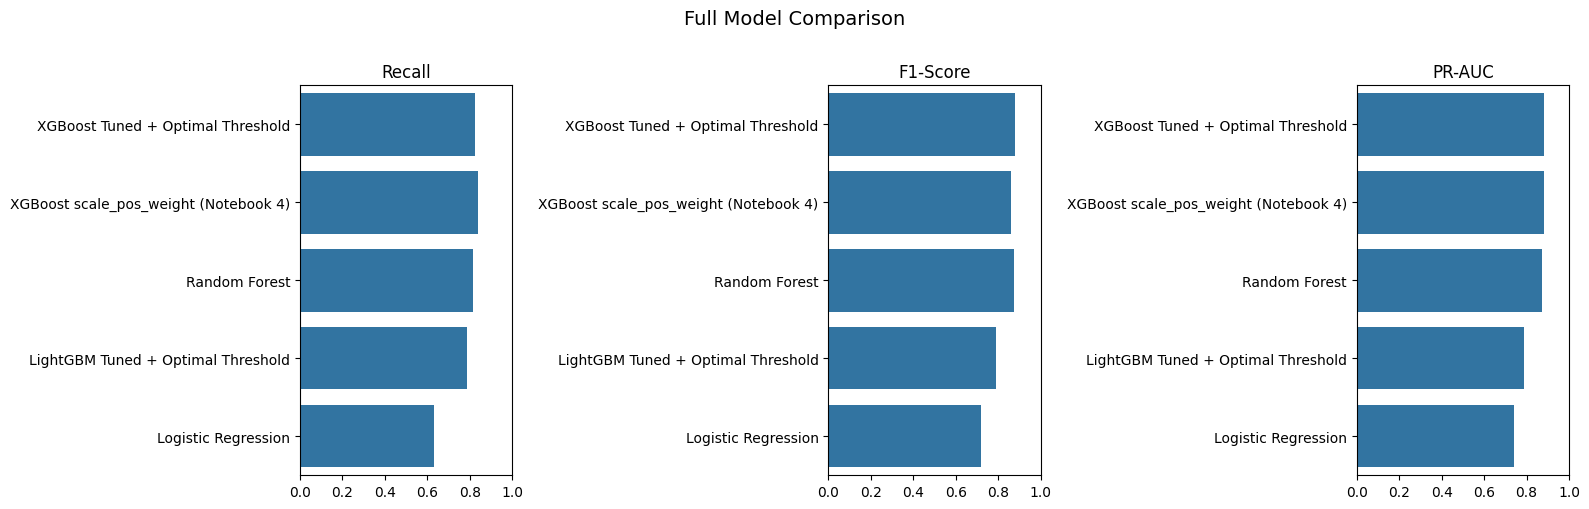

In [8]:
# ── 8. FULL MODEL COMPARISON ──────────────────────────────────────────────────

print("\n=== STEP 5: FULL MODEL COMPARISON ===")

baseline_df = pd.read_csv("../reports/tables/baseline_model_results.csv")

prev_xgb = {
    "Model"    : "XGBoost scale_pos_weight (Notebook 4)",
    "Accuracy" : 0.999526,
    "Precision": 0.881720,
    "Recall"   : 0.836735,
    "F1-Score" : 0.858639,
    "ROC-AUC"  : 0.968238,
    "PR-AUC"   : 0.880004
}

all_results = pd.concat([
    baseline_df,
    pd.DataFrame([prev_xgb]),
    pd.DataFrame([results_xgb_thresh]),
    pd.DataFrame([results_lgbm_thresh])
], ignore_index=True).sort_values("PR-AUC", ascending=False)

print(all_results.to_string(index=False))
all_results.to_csv("../reports/tables/full_model_comparison.csv", index=False)
print("\nSaved -> ../reports/tables/full_model_comparison.csv")

metrics_to_plot = ["Recall", "F1-Score", "PR-AUC"]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, metric in zip(axes, metrics_to_plot):
    sns.barplot(data=all_results, x=metric, y="Model", ax=ax, orient="h")
    ax.set_title(metric)
    ax.set_xlim(0, 1)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.suptitle("Full Model Comparison", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig("../reports/tables/full_model_comparison_plot.png", dpi=150, bbox_inches="tight")
plt.show()

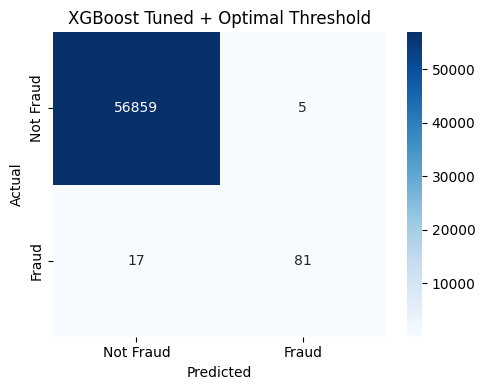

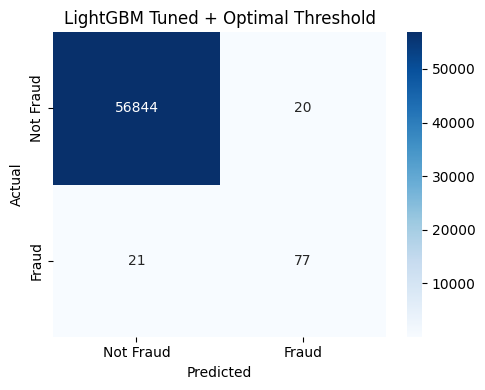


XGBoost classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.83      0.88        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

LightGBM classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.79      0.79      0.79        98

    accuracy                           1.00     56962
   macro avg       0.90      0.89      0.89     56962
weighted avg       1.00      1.00      1.00     56962



In [9]:
# ── 9. CONFUSION MATRICES ─────────────────────────────────────────────────────

def plot_cm(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Not Fraud", "Fraud"],
                yticklabels=["Not Fraud", "Fraud"])
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(f"../reports/tables/{title.replace(' ', '_')}_cm.png", dpi=150)
    plt.show()
    

plot_cm(y_test, y_pred_xgb_tuned,  "XGBoost Tuned + Optimal Threshold")
plot_cm(y_test, y_pred_lgbm_tuned, "LightGBM Tuned + Optimal Threshold")

print("\nXGBoost classification report:")
print(classification_report(y_test, y_pred_xgb_tuned, zero_division=0))
print("LightGBM classification report:")
print(classification_report(y_test, y_pred_lgbm_tuned, zero_division=0))

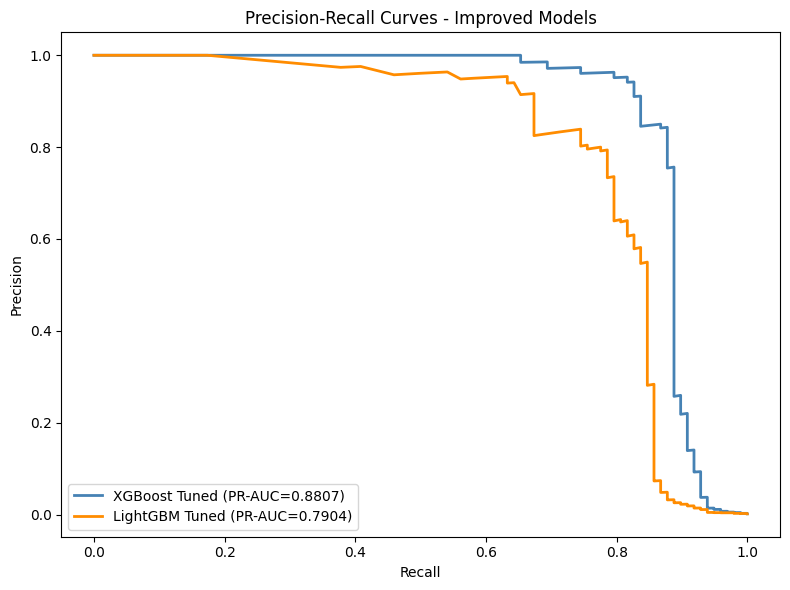

In [10]:
# ── 10. PRECISION-RECALL CURVES ───────────────────────────────────────────────

plt.figure(figsize=(8, 6))
for prob, label, color in [
    (best_xgb_prob,  "XGBoost Tuned",  "steelblue"),
    (best_lgbm_prob, "LightGBM Tuned", "darkorange"),
]:
    p, r, _ = precision_recall_curve(y_test, prob)
    auc_val  = average_precision_score(y_test, prob)
    plt.plot(r, p, label=f"{label} (PR-AUC={auc_val:.4f})", lw=2, color=color)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves - Improved Models")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/tables/pr_curves_improved.png", dpi=150)
plt.show()

In [11]:
# ── 11. SAVE MODELS AND ARTIFACTS ─────────────────────────────────────────────

joblib.dump(best_xgb_model,      "../models/improved/xgb_tuned_improved.pkl")
joblib.dump(best_lgbm_model,     "../models/improved/lgbm_tuned_improved.pkl")
joblib.dump(xgb_best_threshold,  "../models/improved/xgb_best_threshold.pkl")
joblib.dump(lgbm_best_threshold, "../models/improved/lgbm_best_threshold.pkl")
joblib.dump(selected_features,   "../models/improved/selected_features.pkl")

print("\nAll models and artifacts saved to ../models/improved/")
print(f"XGBoost optimal threshold : {xgb_best_threshold:.4f}")
print(f"LightGBM optimal threshold: {lgbm_best_threshold:.4f}")
print(f"Selected features ({len(selected_features)}): {selected_features}")


All models and artifacts saved to ../models/improved/
XGBoost optimal threshold : 0.9410
LightGBM optimal threshold: 0.8794
Selected features (8): ['V14', 'V4', 'V12', 'V11', 'V10', 'Time', 'V3', 'V8']


In [12]:
# ── 12. SUMMARY ───────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("NOTEBOOK 06 - SUMMARY OF CHANGES vs NOTEBOOK 4")
print("="*60)
print("""
1. FEATURE SELECTION
   Used SHAP to drop 22 near-zero features. Tested both
   full and reduced sets; best performer auto-selected.

2. FIXED TUNING SCORING
   Changed scoring from 'recall' to 'average_precision'.
   This prevents precision from collapsing to ~0.11.

3. LIGHTGBM
   Added as a new model with its own tuned search.
   Uses num_leaves for finer complexity control.

4. OPTIMAL THRESHOLD
   PR-curve F1 maximisation replaces manual grid search.
   Applied to both XGBoost and LightGBM final models.

5. WINDOWS COMPATIBILITY FIX
   n_jobs=1 in all RandomizedSearchCV calls to prevent
   XGBoost access violation in loky worker processes.
""")


NOTEBOOK 06 - SUMMARY OF CHANGES vs NOTEBOOK 4

1. FEATURE SELECTION
   Used SHAP to drop 22 near-zero features. Tested both
   full and reduced sets; best performer auto-selected.

2. FIXED TUNING SCORING
   Changed scoring from 'recall' to 'average_precision'.
   This prevents precision from collapsing to ~0.11.

3. LIGHTGBM
   Added as a new model with its own tuned search.
   Uses num_leaves for finer complexity control.

4. OPTIMAL THRESHOLD
   PR-curve F1 maximisation replaces manual grid search.
   Applied to both XGBoost and LightGBM final models.

5. WINDOWS COMPATIBILITY FIX
   n_jobs=1 in all RandomizedSearchCV calls to prevent
   XGBoost access violation in loky worker processes.



In [13]:
# ?? EXTRA 1: LightGBM with is_unbalance=True ??????????????????????????????
print("\n=== EXTRA: LightGBM is_unbalance=True ===")

lgbm_balanced = LGBMClassifier(
    random_state=42,
    is_unbalance=True,    # native balancing instead of scale_pos_weight
    verbose=-1
)

lgbm_balanced_search = RandomizedSearchCV(
    estimator           = lgbm_balanced,
    param_distributions = {
        "n_estimators"     : [100, 200, 300],
        "max_depth"        : [-1, 5, 7, 10],
        "learning_rate"    : [0.01, 0.05, 0.1],
        "num_leaves"       : [31, 63, 127],
        "subsample"        : [0.7, 0.8, 0.9],
        "colsample_bytree" : [0.7, 0.8, 0.9],
        "min_child_samples": [10, 20, 50],
        "reg_alpha"        : [0, 0.1, 1.0],
        "reg_lambda"       : [0, 1, 5]
    },
    n_iter              = 20,
    scoring             = "average_precision",
    cv                  = 3,
    verbose             = 1,
    random_state        = 42,
    n_jobs              = 1
)

lgbm_balanced_search.fit(X_train_scaled, y_train)

best_lgbm_balanced   = lgbm_balanced_search.best_estimator_
y_prob_lgbm_balanced = best_lgbm_balanced.predict_proba(X_test_scaled)[:, 1]

lgbm_balanced_threshold = find_best_threshold(
    y_test, y_prob_lgbm_balanced, "LightGBM is_unbalance"
)
y_pred_lgbm_balanced = (y_prob_lgbm_balanced >= lgbm_balanced_threshold).astype(int)

results_lgbm_balanced = evaluate_model(
    "LightGBM is_unbalance + Optimal Threshold",
    y_test, y_pred_lgbm_balanced, y_prob_lgbm_balanced
)
print(pd.DataFrame([results_lgbm_balanced]))



=== EXTRA: LightGBM is_unbalance=True ===
Fitting 3 folds for each of 20 candidates, totalling 60 fits
LightGBM is_unbalance -> best threshold: 0.8794,  best F1: 0.7897
                                       Model  Accuracy  Precision    Recall  \
0  LightGBM is_unbalance + Optimal Threshold   0.99928   0.793814  0.785714   

   F1-Score   ROC-AUC    PR-AUC  
0  0.789744  0.964108  0.790436  


In [14]:
# ?? EXTRA 2: CatBoost ?????????????????????????????????????????????????????
print("\n=== EXTRA: CatBoost ===")

from catboost import CatBoostClassifier

catboost_search = RandomizedSearchCV(
    estimator           = CatBoostClassifier(
                              random_state=42,
                              auto_class_weights="Balanced",
                              verbose=0
                          ),
    param_distributions = {
        "iterations"   : [100, 200, 300],
        "depth"        : [4, 6, 8],
        "learning_rate": [0.01, 0.05, 0.1],
        "l2_leaf_reg"  : [1, 3, 5, 7]
    },
    n_iter              = 20,
    scoring             = "average_precision",
    cv                  = 3,
    verbose             = 0,
    random_state        = 42,
    n_jobs              = 1
)

catboost_search.fit(X_train_scaled, y_train)

best_catboost   = catboost_search.best_estimator_
y_prob_catboost = best_catboost.predict_proba(X_test_scaled)[:, 1]

catboost_threshold = find_best_threshold(
    y_test, y_prob_catboost, "CatBoost"
)
y_pred_catboost = (y_prob_catboost >= catboost_threshold).astype(int)

results_catboost = evaluate_model(
    "CatBoost + Optimal Threshold",
    y_test, y_pred_catboost, y_prob_catboost
)
print(pd.DataFrame([results_catboost]))



=== EXTRA: CatBoost ===
CatBoost -> best threshold: 0.9583,  best F1: 0.8526
                          Model  Accuracy  Precision    Recall  F1-Score  \
0  CatBoost + Optimal Threshold  0.999508   0.880435  0.826531  0.852632   

    ROC-AUC    PR-AUC  
0  0.971075  0.858246  


In [15]:
# ?? EXTRA 3: Ensemble ?????????????????????????????????????????????????????
print("\n=== EXTRA: Ensemble (XGBoost + LightGBM + CatBoost) ===")

# Average probabilities from all three best models
ensemble_prob = (
    best_xgb_prob +
    y_prob_lgbm_balanced +
    y_prob_catboost
) / 3

ensemble_threshold = find_best_threshold(
    y_test, ensemble_prob, "Ensemble"
)
y_pred_ensemble = (ensemble_prob >= ensemble_threshold).astype(int)

results_ensemble = evaluate_model(
    "Ensemble XGBoost + LightGBM + CatBoost",
    y_test, y_pred_ensemble, ensemble_prob
)
print(pd.DataFrame([results_ensemble]))



=== EXTRA: Ensemble (XGBoost + LightGBM + CatBoost) ===
Ensemble -> best threshold: 0.7614,  best F1: 0.8449
                                    Model  Accuracy  Precision    Recall  \
0  Ensemble XGBoost + LightGBM + CatBoost  0.999491    0.88764  0.806122   

   F1-Score   ROC-AUC    PR-AUC  
0   0.84492  0.977663  0.866702  


In [16]:
# ?? UPDATED FULL COMPARISON ???????????????????????????????????????????????
print("\n=== FINAL FULL COMPARISON ===")

all_results_final = pd.concat([
    baseline_df,
    pd.DataFrame([prev_xgb]),
    pd.DataFrame([results_xgb_thresh]),
    pd.DataFrame([results_lgbm_thresh]),
    pd.DataFrame([results_lgbm_balanced]),
    pd.DataFrame([results_catboost]),
    pd.DataFrame([results_ensemble])
], ignore_index=True).sort_values("PR-AUC", ascending=False)

print(all_results_final.to_string(index=False))
all_results_final.to_csv(
    "../reports/tables/full_model_comparison_final.csv", index=False
)

# Save new models
joblib.dump(best_lgbm_balanced, "../models/improved/lgbm_balanced.pkl")
joblib.dump(best_catboost,      "../models/improved/catboost.pkl")

print("\nDone.")



=== FINAL FULL COMPARISON ===
                                    Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC   PR-AUC
        XGBoost Tuned + Optimal Threshold  0.999614   0.941860 0.826531  0.880435 0.980555 0.880745
    XGBoost scale_pos_weight (Notebook 4)  0.999526   0.881720 0.836735  0.858639 0.968238 0.880004
                            Random Forest  0.999596   0.941176 0.816327  0.874317 0.963027 0.873391
   Ensemble XGBoost + LightGBM + CatBoost  0.999491   0.887640 0.806122  0.844920 0.977663 0.866702
             CatBoost + Optimal Threshold  0.999508   0.880435 0.826531  0.852632 0.971075 0.858246
LightGBM is_unbalance + Optimal Threshold  0.999280   0.793814 0.785714  0.789744 0.964108 0.790436
       LightGBM Tuned + Optimal Threshold  0.999280   0.793814 0.785714  0.789744 0.964108 0.790436
                      Logistic Regression  0.999140   0.826667 0.632653  0.716763 0.960549 0.741382

Done.
